<a href="https://colab.research.google.com/github/Alexis0104343/Analisis_de_datos_2026/blob/main/Analisis_de_datos_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Librerias

In [4]:
import yfinance as yf

In [5]:
import pandas as pd

In [6]:
import matplotlib.pyplot as plt
import seaborn as sea

In [7]:
import numpy as np

In [8]:
import plotly.graph_objects as go
import plotly.express as px
import plotly.graph_objects as go

In [9]:
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler,MinMaxScaler

In [10]:
import datetime as dt

In [11]:
from statsmodels.tsa.seasonal import seasonal_decompose

In [12]:
from ydata_profile import prof

SyntaxError: invalid syntax (4072206299.py, line 1)

#Cargar Archivos

In [13]:
df_gold=pd.read_csv("/content/drive/MyDrive/Data/finanzas_gold.csv",index_col=0)

#Guardar

In [ ]:
df_gold.to_csv("/content/drive/MyDrive/Data/finanzas_gold.csv",index="False")

#Clase 1

In [ ]:
df_gold=df_gold.drop(columns=['Unnamed: 0'])

In [14]:
df_gold.head()

,Date,Close,High,Low,Open,Volume,Año,Mes,Dia,Volatilidad,Tendencia,Categoria,Retorno_Diario,Retorno_acumulado,Volatilidad_20D,SMA_50,EMA_50,RatioVP,Banda_Superior,Banda_Inferior
0,2024-01-02,2064.399902,2073.699951,2057.100098,2063.500000,61.0,2024,1,2,16.599854,Estable,1,NaN,NaN,NaN,NaN,2064.399902,0.029549,NaN,NaN
1,2024-01-03,2034.199951,2044.000000,2034.199951,2034.199951,54.0,2024,1,3,9.800049,Baja,0,-1.462892,0.985371,NaN,NaN,2048.997927,0.026546,NaN,NaN
2,2024-01-04,2042.300049,2044.500000,2038.000000,2041.599976,88.0,2024,1,4,6.500000,Sube,2,0.398196,0.989295,NaN,NaN,2046.675413,0.043089,NaN,NaN
3,2024-01-05,2042.400024,2048.100098,2042.400024,2044.500000,12.0,2024,1,5,5.700073,Sube,2,0.004895,0.989343,NaN,NaN,2045.541597,0.005875,NaN,NaN
4,2024-01-08,2026.599976,2033.699951,2019.099976,2019.099976,10.0,2024,1,8,14.599976,Baja,0,-0.773602,0.981690,NaN,NaN,2041.444271,0.004934,NaN,NaN


In [ ]:
import yfinance as yf
df_gold=yf.download("GC=F",start="2024-01-01",end="2026-01-01")
df_gold.head()

/tmp/ipython-input-4210527928.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df_gold=yf.download("GC=F",start="2024-01-01",end="2026-01-01")
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,GC=F,GC=F,GC=F,GC=F,GC=F
Date,,,,,
2024-01-02,2064.399902,2073.699951,2057.100098,2063.500000,61
2024-01-03,2034.199951,2044.000000,2034.199951,2034.199951,54
2024-01-04,2042.300049,2044.500000,2038.000000,2041.599976,88
2024-01-05,2042.400024,2048.100098,2042.400024,2044.500000,12
2024-01-08,2026.599976,2033.699951,2019.099976,2019.099976,10


In [ ]:
df_gold.to_csv("/content/drive/MyDrive/Data/finanzas_gold.csv")

In [ ]:
import pandas as pd
df_gold=pd.read_csv("/content/drive/MyDrive/Data/finanzas_gold.csv")

In [ ]:
df_gold.head()


,Unnamed: 0.1,Unnamed: 0,Date,Close,High,Low,Open,Volume,Year,Month,Day,Volatilidad,Tendencia
0,0,0,2024-01-02,2064.399902,2073.699951,2057.100098,2063.500000,61.0,2024,1,2,16.599854,Estable
1,1,1,2024-01-03,2034.199951,2044.000000,2034.199951,2034.199951,54.0,2024,1,3,9.800049,Baja
2,2,2,2024-01-04,2042.300049,2044.500000,2038.000000,2041.599976,88.0,2024,1,4,6.500000,Sube
3,3,3,2024-01-05,2042.400024,2048.100098,2042.400024,2044.500000,12.0,2024,1,5,5.700073,Sube
4,4,4,2024-01-08,2026.599976,2033.699951,2019.099976,2019.099976,10.0,2024,1,8,14.599976,Baja


In [ ]:
df_gold.columns=["Date","Close","High","Low","Open","Volume"]
df_gold.head()

,Date,Close,High,Low,Open,Volume
0,Ticker,GC=F,GC=F,GC=F,GC=F,GC=F
1,Date,NaN,NaN,NaN,NaN,NaN
2,2024-01-02,2064.39990234375,2073.699951171875,2057.10009765625,2063.5,61
3,2024-01-03,2034.199951171875,2044.0,2034.199951171875,2034.199951171875,54
4,2024-01-04,2042.300048828125,2044.5,2038.0,2041.5999755859375,88


In [ ]:
df_gold=df_gold.iloc[2:,:].reset_index(drop=True)
df_gold.head()

,Date,Close,High,Low,Open,Volume
0,2024-01-02,2064.39990234375,2073.699951171875,2057.10009765625,2063.5,61
1,2024-01-03,2034.199951171875,2044.0,2034.199951171875,2034.199951171875,54
2,2024-01-04,2042.300048828125,2044.5,2038.0,2041.5999755859375,88
3,2024-01-05,2042.4000244140625,2048.10009765625,2042.4000244140625,2044.5,12
4,2024-01-08,2026.5999755859375,2033.699951171875,2019.0999755859375,2019.0999755859375,10


In [ ]:
df_gold.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 504 entries, 0 to 503
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  504 non-null    int64  
 1   Date        504 non-null    object 
 2   Close       504 non-null    float64
 3   High        504 non-null    float64
 4   Low         504 non-null    float64
 5   Open        504 non-null    float64
 6   Volume      504 non-null    float64
dtypes: float64(5), int64(1), object(1)
memory usage: 27.7+ KB


In [ ]:
df_gold["Date"]=pd.to_datetime(df_gold["Date"])
df_gold["Close"]=df_gold.Close.astype("float")
df_gold["High"]=df_gold.High.astype("float")
df_gold["Low"]=df_gold.Low.astype("float")
df_gold["Open"]=df_gold.Open.astype("float")
df_gold["Volume"]=df_gold.Volume.astype("float")
df_gold.tail(10)

,Unnamed: 0,Date,Close,High,Low,Open,Volume
494,494,2025-12-17,4347.500000,4351.399902,4308.500000,4308.500000,2169.0
495,495,2025-12-18,4339.500000,4348.100098,4328.200195,4331.000000,705.0
496,496,2025-12-19,4361.399902,4361.399902,4350.100098,4350.100098,1065.0
497,497,2025-12-22,4444.600098,4447.600098,4371.100098,4371.100098,449.0
498,498,2025-12-23,4482.799805,4503.799805,4450.399902,4503.299805,694.0
499,499,2025-12-24,4480.600098,4503.399902,4468.399902,4500.700195,500.0
500,500,2025-12-26,4529.100098,4556.299805,4502.000000,4512.000000,263.0
501,501,2025-12-29,4325.100098,4379.000000,4325.100098,4371.500000,2044.0
502,502,2025-12-30,4370.100098,4403.600098,4338.000000,4346.399902,1837.0
503,503,2025-12-31,4325.600098,4363.799805,4285.000000,4333.500000,785.0


In [ ]:
df_gold["Year"]=df_gold.Date.dt.year
df_gold["Month"]=df_gold.Date.dt.month
df_gold["Day"]=df_gold.Date.dt.day

In [ ]:
df_gold["Tendencia"]="Estable"
df_gold.loc[df_gold.Close<df_gold.Close.shift(1),"Tendencia"]="Baja"
df_gold.loc[df_gold.Close>df_gold.Close.shift(1),"Tendencia"]="Sube"

In [ ]:
df_gold.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 504 entries, 0 to 503
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    504 non-null    datetime64[ns]
 1   Close   504 non-null    float64       
 2   High    504 non-null    float64       
 3   Low     504 non-null    float64       
 4   Open    504 non-null    float64       
 5   Volume  504 non-null    float64       
dtypes: datetime64[ns](1), float64(5)
memory usage: 23.8 KB


In [ ]:
df_gold.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 504 entries, 0 to 503
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  504 non-null    int64  
 1   Date        504 non-null    object 
 2   Close       504 non-null    float64
 3   High        504 non-null    float64
 4   Low         504 non-null    float64
 5   Open        504 non-null    float64
 6   Volume      504 non-null    float64
dtypes: float64(5), int64(1), object(1)
memory usage: 27.7+ KB


In [ ]:
df_gold["Close"].mean()

np.float64(2918.6773761567615)

In [ ]:
df_gold["Close"].median()

2734.3499755859375

In [ ]:
df_gold["Close"].std()

649.129649478099

In [ ]:
df_gold["Close"].min()

1990.300048828125

In [ ]:
df_gold["Close"].max()

4529.10009765625

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sea

<Axes: xlabel='Close', ylabel='Count'>

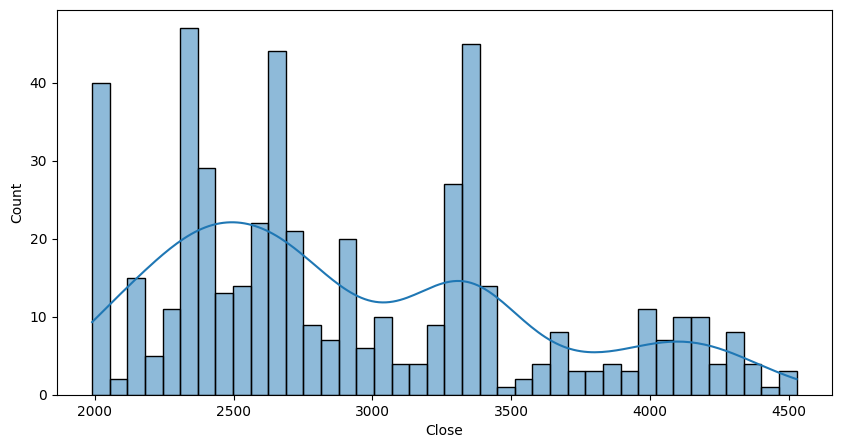

In [ ]:
plt.figure(figsize=(10,5))
sea.histplot(df_gold["Close"],bins=40,kde=True)

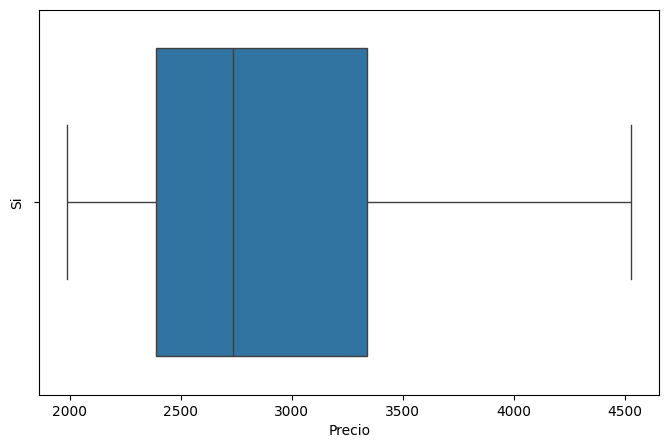

In [ ]:
plt.figure(figsize=(8,5))
sea.boxplot(x=df_gold["Close"])
plt.xlabel("Precio")
plt.ylabel("Si")
plt.show()

In [ ]:
df_gold.isnull().sum()

,0
Unnamed: 0,0
Date,0
Close,0
High,0
Low,0
Open,0
Volume,0


In [ ]:
df_gold.dropna()

,Unnamed: 0,Date,Close,High,Low,Open,Volume
0,0,2024-01-02,2064.399902,2073.699951,2057.100098,2063.500000,61.0
1,1,2024-01-03,2034.199951,2044.000000,2034.199951,2034.199951,54.0
2,2,2024-01-04,2042.300049,2044.500000,2038.000000,2041.599976,88.0
3,3,2024-01-05,2042.400024,2048.100098,2042.400024,2044.500000,12.0
4,4,2024-01-08,2026.599976,2033.699951,2019.099976,2019.099976,10.0
...,...,...,...,...,...,...,...
499,499,2025-12-24,4480.600098,4503.399902,4468.399902,4500.700195,500.0
500,500,2025-12-26,4529.100098,4556.299805,4502.000000,4512.000000,263.0
501,501,2025-12-29,4325.100098,4379.000000,4325.100098,4371.500000,2044.0
502,502,2025-12-30,4370.100098,4403.600098,4338.000000,4346.399902,1837.0


In [ ]:
df_gold["Close"].fillna(df_gold["Close"].mean())

In [ ]:
import numpy as np


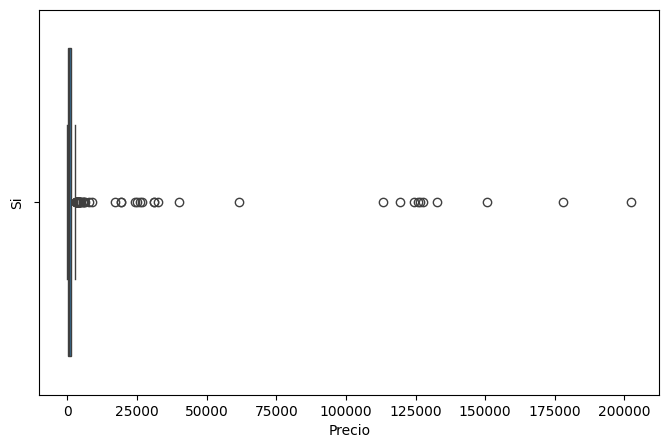

In [ ]:
plt.figure(figsize=(8,5))
sea.boxplot(x=df_gold["Volume"])
plt.xlabel("Precio")
plt.ylabel("Si")
plt.show()

In [ ]:

Q1=df_gold["Volume"].quantile(0.25)
Q3=df_gold["Volume"].quantile(0.75)
IQR=Q3-Q1

In [ ]:
prop=1.5
li=Q1-prop*IQR
ls=Q1+prop*IQR

In [ ]:
df_outlier=df_gold.loc[(df_gold.Volume<li) | (df_gold.Volume>ls)]

In [ ]:
df_outlier.shape

(94, 7)

In [ ]:
df_clean=df_gold[(df_gold.Volume>li) & (df_gold.Volume<ls)]

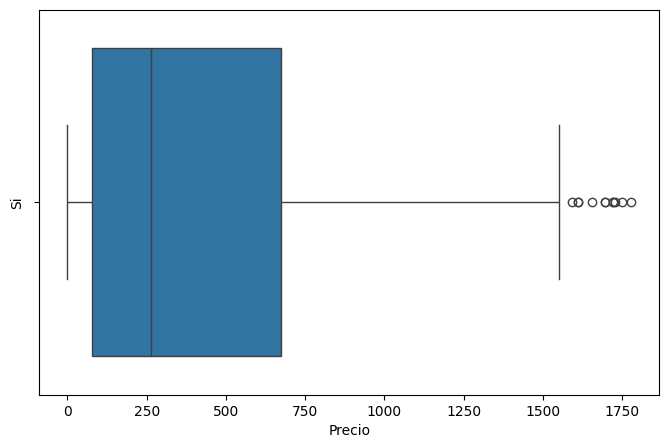

In [ ]:
df_clean
plt.figure(figsize=(8,5))
sea.boxplot(x=df_clean["Volume"])
plt.xlabel("Precio")
plt.ylabel("Si")
plt.show()

In [ ]:
df_gold.Volume.mean()

np.float64(4275.958333333333)

In [ ]:
df_clean.Volume.mean()

np.float64(436.38048780487804)

In [ ]:
corr_matrix=df_gold[["Open","High","Low","Close","Volume"]].corr()

In [ ]:
corr_matrix

,Open,High,Low,Close,Volume
Open,1.000000,0.999563,0.999347,0.998842,-0.023602
High,0.999563,1.000000,0.999309,0.999451,-0.025616
Low,0.999347,0.999309,1.000000,0.999635,-0.020919
Close,0.998842,0.999451,0.999635,1.000000,-0.023133
Volume,-0.023602,-0.025616,-0.020919,-0.023133,1.000000


<Axes: >

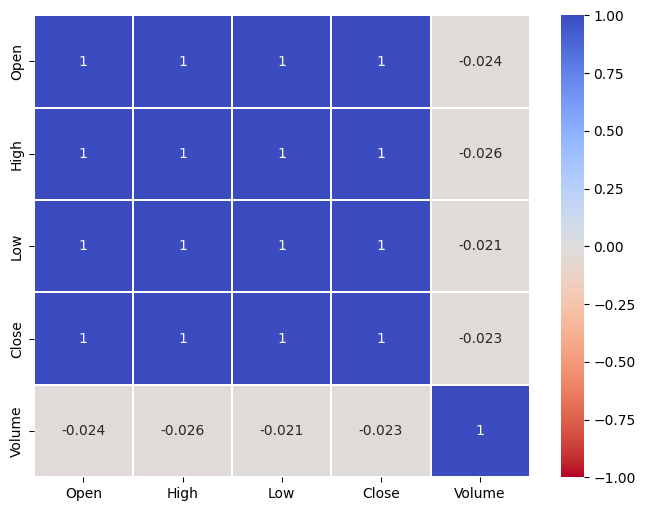

In [ ]:
plt.figure(figsize=(8,6))
sea.heatmap(corr_matrix,annot=True,vmin=-1,vmax=1,cmap="coolwarm_r",linewidths=0.2)


In [ ]:
#Revisar correlaciones https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.corr.html

#Clase 2


In [ ]:
import plotly.express as px

In [ ]:
df_gold.head()

,Unnamed: 0,Date,Close,High,Low,Open,Volume,Year,Month,Day,Volatilidad
0,0,2024-01-02,2064.399902,2073.699951,2057.100098,2063.500000,61.0,2024,1,2,16.599854
1,1,2024-01-03,2034.199951,2044.000000,2034.199951,2034.199951,54.0,2024,1,3,9.800049
2,2,2024-01-04,2042.300049,2044.500000,2038.000000,2041.599976,88.0,2024,1,4,6.500000
3,3,2024-01-05,2042.400024,2048.100098,2042.400024,2044.500000,12.0,2024,1,5,5.700073
4,4,2024-01-08,2026.599976,2033.699951,2019.099976,2019.099976,10.0,2024,1,8,14.599976


In [ ]:
fig=px.scatter_matrix(df_gold["Close"])

In [ ]:
fig.show()

In [ ]:
df_gold["Volatilidad"]=df_gold["High"]-df_gold["Low"]

In [ ]:
df_gold[["High","Low","Volatilidad"]].corr()

,High,Low,Volatilidad
High,1.000000,0.999309,0.519768
Low,0.999309,1.000000,0.487644
Volatilidad,0.519768,0.487644,1.000000


In [ ]:
fig=px.line(df_gold,x="Date",y="Volatilidad",title="Volatilidad diaria",template="plotly_white")

In [ ]:
fig.show()

In [ ]:
fig=px.scatter(df_gold,x="Volume",y="Close",title="Compra_Cierre")

In [ ]:
fig.show()


In [ ]:
from sklearn.preprocessing import StandardScaler,MinMaxScaler

In [ ]:
scaler=StandardScaler()
df_scaled=df_gold.copy()
df_scaled[["Low","High","Open","Close","Volume"]]=scaler.fit_transform(df_gold[["Low","High","Open","Close","Volume"]])

In [ ]:
df_scaled

,Unnamed: 0,Date,Close,High,Low,Open,Volume,Volatilidad
0,0,2024-01-02,-1.317343,-1.314954,-1.315612,-1.317643,-0.207802,16.599854
1,1,2024-01-03,-1.363913,-1.360313,-1.351352,-1.362925,-0.208148,9.800049
2,2,2024-01-04,-1.351422,-1.359549,-1.345422,-1.351489,-0.206471,6.500000
3,3,2024-01-05,-1.351268,-1.354051,-1.338555,-1.347007,-0.210218,5.700073
4,4,2024-01-08,-1.375632,-1.376043,-1.374919,-1.386262,-0.210317,14.599976
...,...,...,...,...,...,...,...,...
499,499,2025-12-24,2.408571,2.395720,2.447722,2.449017,-0.186159,35.000000
500,500,2025-12-26,2.483360,2.476510,2.500162,2.466480,-0.197844,54.299805
501,501,2025-12-29,2.168781,2.205735,2.224073,2.249340,-0.110038,53.899902
502,502,2025-12-30,2.238173,2.243304,2.244206,2.210548,-0.120244,65.600098


In [ ]:
fig=px.histogram(df_scaled,x="Close")

In [ ]:
fig.show()

In [ ]:
scaler=M()
df_scaled=df_gold.copy()
df_scaled[["Low","High","Open","Close","Volume"]]=scaler.fit_transform(df_gold[["Low","High","Open","Close","Volume"]])

In [ ]:
df_gold.head()

,Unnamed: 0.1,Unnamed: 0,Date,Close,High,Low,Open,Volume
0,0,0,2024-01-02,2064.399902,2073.699951,2057.100098,2063.500000,61.0
1,1,1,2024-01-03,2034.199951,2044.000000,2034.199951,2034.199951,54.0
2,2,2,2024-01-04,2042.300049,2044.500000,2038.000000,2041.599976,88.0
3,3,3,2024-01-05,2042.400024,2048.100098,2042.400024,2044.500000,12.0
4,4,4,2024-01-08,2026.599976,2033.699951,2019.099976,2019.099976,10.0


In [ ]:
df_encode=pd.get_dummies(df_gold,columns=["Tendencia"])

In [ ]:
df_encode.head()

,Unnamed: 0,Date,Close,High,Low,Open,Volume,Year,Month,Day,Volatilidad,Tendencia_Baja,Tendencia_Estable,Tendencia_Sube
0,0,2024-01-02,2064.399902,2073.699951,2057.100098,2063.500000,61.0,2024,1,2,16.599854,False,True,False
1,1,2024-01-03,2034.199951,2044.000000,2034.199951,2034.199951,54.0,2024,1,3,9.800049,True,False,False
2,2,2024-01-04,2042.300049,2044.500000,2038.000000,2041.599976,88.0,2024,1,4,6.500000,False,False,True
3,3,2024-01-05,2042.400024,2048.100098,2042.400024,2044.500000,12.0,2024,1,5,5.700073,False,False,True
4,4,2024-01-08,2026.599976,2033.699951,2019.099976,2019.099976,10.0,2024,1,8,14.599976,True,False,False


In [ ]:
df_gold.Tendencia.value_counts()

,count
Tendencia,
Sube,295
Baja,208
Estable,1


In [ ]:
fig=px.bar(df_gold,x=df_gold.Tendencia.value_counts(),title="Frecuencia de valores")

KeyError: 'count'

In [ ]:
fig.show()

In [ ]:
from sklearn.preprocessing import LabelEncoder

In [ ]:
label_encoder=LabelEncoder()
df_gold["Categoria"]=label_encoder.fit_transform(df_gold["Tendencia"])
df_gold[["Tendencia","Categoria"]].head()

,Tendencia,Categoria
0,Estable,1
1,Baja,0
2,Sube,2
3,Sube,2
4,Baja,0


In [ ]:
label_mapping=dict(zip(label_encoder.classes_,label_encoder.transform(label_encoder.classes_)))

In [ ]:
label_mapping

{'Baja': np.int64(0), 'Estable': np.int64(1), 'Sube': np.int64(2)}

In [ ]:
!pip uninstall -y pandas-profiling numba llvmlite visions
!pip install --upgrade pip
!pip install -U scikit-learn
!pip install -U joblib
!pip install -U ydata-profiling
!pip install -U sweetviz
!pip install -U numba

Found existing installation: pandas-profiling 3.2.0
Uninstalling pandas-profiling-3.2.0:
  Successfully uninstalled pandas-profiling-3.2.0
Found existing installation: numba 0.60.0
Uninstalling numba-0.60.0:
  Successfully uninstalled numba-0.60.0
Found existing installation: llvmlite 0.43.0
Uninstalling llvmlite-0.43.0:
  Successfully uninstalled llvmlite-0.43.0
Found existing installation: visions 0.7.4
Uninstalling visions-0.7.4:
  Successfully uninstalled visions-0.7.4
  Attempting uninstall: joblib
    Found existing installation: joblib 1.1.1
    Uninstalling joblib-1.1.1:
      Successfully uninstalled joblib-1.1.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
shap 0.50.0 requires numba>=0.54; python_version < "3.14", which is not installed.
segregation 2.5.3 requires numba, which is not installed.
pynndescent 0.6.0 requires llvmlite>=0.38, which is no

In [ ]:
import pandas as pd
from ydata_profile

#Clase 3

In [ ]:
df_gold.head()

,Unnamed: 0.1,Unnamed: 0,Date,Close,High,Low,Open,Volume,Año,Mes,Dia,Volatilidad,Tendencia,Categoria
0,0,0,2024-01-02,2064.399902,2073.699951,2057.100098,2063.500000,61.0,2024,1,2,16.599854,Estable,1
1,1,1,2024-01-03,2034.199951,2044.000000,2034.199951,2034.199951,54.0,2024,1,3,9.800049,Baja,0
2,2,2,2024-01-04,2042.300049,2044.500000,2038.000000,2041.599976,88.0,2024,1,4,6.500000,Sube,2
3,3,3,2024-01-05,2042.400024,2048.100098,2042.400024,2044.500000,12.0,2024,1,5,5.700073,Sube,2
4,4,4,2024-01-08,2026.599976,2033.699951,2019.099976,2019.099976,10.0,2024,1,8,14.599976,Baja,0


In [ ]:
df_metrics=df_gold.groupby(["Año","Mes"]).agg(Precio_Cierre_Medio=("Close","mean"),
                                              Precio_Cierre_Max=("Close","max"),
                                              Precio_Cierre_Min=("Close","min"),
                                              Volatilidad_Cierre=("Close","std"),
                                              Precio_Apertura_Medio=("Open","mean"),
                                              Precio_Apertura_Max=("Open","max"),
                                              Precio_Apertura_Min=("Open","min"),
                                              Volatilidad_Apertura=("Open","std")


)

In [ ]:
fig=px.bar(df_metrics.reset_index(),x="Año",
           y="Precio_Cierre_Medio",
           title="Retorno medio anua del oro",
           template="plotly_white")

In [ ]:
fig.show()

In [ ]:
df_metrics_2=df_metrics.reset_index()
df_metrics_2["Mes"]=df_metrics_2["Mes"].astype("str")

In [ ]:
fig.show()

In [ ]:
df_metrics_2.pivot_table(values="Volatilidad_Cierre",index="Mes",columns="Año")

Año,2024,2025
Mes,,
1,14.258328,55.848284
10,52.043356,126.480001
11,55.421235,78.175070
12,32.347924,103.512293
2,16.149821,35.627281
3,27.325152,68.855814
4,40.087550,137.094490
5,39.806757,63.130220
6,19.689616,38.517162


In [ ]:
df_pivot=df_gold.pivot_table(values="Close",index="Mes",columns="Año",
aggfunc="mean")

In [ ]:
import plotly.graph_objects as go

In [ ]:
fig=go.Figure(data=go.Heatmap(
    z=df_pivot.values,
    x=df_pivot.columns,
    y=df_pivot.index,
    colorscale="blues"
))

In [ ]:
fig.update_layout(title="Variacionde precio de cierre",
                  )

In [ ]:
df_gold["Retorno_Diario"]=df_gold["Close"].pct_change()*100

In [ ]:
df_gold[["Date","Close","Retorno_Diario"]].head(20)

,Date,Close,Retorno_Diario
0,2024-01-02,2064.399902,NaN
1,2024-01-03,2034.199951,-1.462892
2,2024-01-04,2042.300049,0.398196
3,2024-01-05,2042.400024,0.004895
4,2024-01-08,2026.599976,-0.773602
5,2024-01-09,2026.400024,-0.009866
6,2024-01-10,2021.699951,-0.231942
7,2024-01-11,2014.300049,-0.366024
8,2024-01-12,2046.699951,1.608494
9,2024-01-16,2026.000000,-1.011382


In [ ]:
fig=px.line(df_gold,x="Date",y="Retorno_Diario")

In [ ]:
fig.show()

In [ ]:
df_gold["Retorno_acumulado"]=(1+df_gold["Retorno_Diario"]/100).cumprod()

In [ ]:
df_gold[["Date","Close","Retorno_Diario","Retorno_acumulado"]].head(20)

,Date,Close,Retorno_Diario,Retorno_acumulado
0,2024-01-02,2064.399902,NaN,NaN
1,2024-01-03,2034.199951,-1.462892,0.985371
2,2024-01-04,2042.300049,0.398196,0.989295
3,2024-01-05,2042.400024,0.004895,0.989343
4,2024-01-08,2026.599976,-0.773602,0.981690
5,2024-01-09,2026.400024,-0.009866,0.981593
6,2024-01-10,2021.699951,-0.231942,0.979316
7,2024-01-11,2014.300049,-0.366024,0.975732
8,2024-01-12,2046.699951,1.608494,0.991426
9,2024-01-16,2026.000000,-1.011382,0.981399


In [ ]:
fig=px.line(df_gold,x="Date",y="Retorno_acumulado")
fig.show()

In [ ]:
df_gold["Volatilidad_20D"]=df_gold["Retorno_Diario"].rolling(window=20).std()


In [ ]:
df_gold[["Date","Close","Retorno_Diario","Volatilidad_20D"]].head(35)

,Date,Close,Retorno_Diario,Volatilidad_20D
0,2024-01-02,2064.399902,NaN,NaN
1,2024-01-03,2034.199951,-1.462892,NaN
2,2024-01-04,2042.300049,0.398196,NaN
3,2024-01-05,2042.400024,0.004895,NaN
4,2024-01-08,2026.599976,-0.773602,NaN
5,2024-01-09,2026.400024,-0.009866,NaN
6,2024-01-10,2021.699951,-0.231942,NaN
7,2024-01-11,2014.300049,-0.366024,NaN
8,2024-01-12,2046.699951,1.608494,NaN
9,2024-01-16,2026.000000,-1.011382,NaN


In [ ]:
fig=px.line(df_gold,x="Date",y="Volatilidad_20D",title="Evolucion de la Volatilidad (20 dias)")
fig.show()

#Clase 4

In [ ]:
df_gold.head()

,Date,Close,High,Low,Open,Volume,Año,Mes,Dia,Volatilidad,Tendencia,Categoria,Retorno_Diario,Retorno_acumulado,Volatilidad_20D
0,2024-01-02,2064.399902,2073.699951,2057.100098,2063.500000,61.0,2024,1,2,16.599854,Estable,1,NaN,NaN,NaN
1,2024-01-03,2034.199951,2044.000000,2034.199951,2034.199951,54.0,2024,1,3,9.800049,Baja,0,-1.462892,0.985371,NaN
2,2024-01-04,2042.300049,2044.500000,2038.000000,2041.599976,88.0,2024,1,4,6.500000,Sube,2,0.398196,0.989295,NaN
3,2024-01-05,2042.400024,2048.100098,2042.400024,2044.500000,12.0,2024,1,5,5.700073,Sube,2,0.004895,0.989343,NaN
4,2024-01-08,2026.599976,2033.699951,2019.099976,2019.099976,10.0,2024,1,8,14.599976,Baja,0,-0.773602,0.981690,NaN


In [22]:
df_gold["SMA_50"]=df_gold["Close"].rolling(window=50).mean()
df_gold["EMA_50"]=df_gold["Close"].ewm(span=50).mean()

In [25]:
fig=px.line(
    df_gold,x="Close",y=["SMA_50","EMA_50"],title="Evolucion del precion con SMA y EMA 50D",
    template="plotly_white",
    labels={"Close":"Precio de cierre","SMA_50":"SMA","EMA_50":"EMA"},

)

In [26]:
fig.show()

In [ ]:
df_gold["RatioVP"]=df_gold["Volume"]/df_gold["Close"]

In [ ]:
df_gold[["Date","Close","Volume","RatioVP"]].head()

,Date,Close,Volume,RatioVP
0,2024-01-02,2064.399902,61.0,0.029549
1,2024-01-03,2034.199951,54.0,0.026546
2,2024-01-04,2042.300049,88.0,0.043089
3,2024-01-05,2042.400024,12.0,0.005875
4,2024-01-08,2026.599976,10.0,0.004934


In [ ]:
fig=px.line(df_gold,x="Date",y="RatioVP",title="Yea",
labels=["RatioVP","Volumen/Precio"]
)

In [ ]:
fig.show()

In [34]:
import plotly.graph_objects as go

# 📌 Crear gráfico de líneas interactivo con slider
fig = go.Figure()

# 📌 Agregar la serie de tiempo del precio de cierre
fig.add_trace(go.Scatter(x=df_gold.Date, y=df_gold["Close"],
                         mode="lines", name="Precio de Cierre"))

# 📌 Configurar el slider en el eje X (tiempo)
fig.update_layout(
    title="Evolución del Precio de Cierre de Apple con Slider",
    xaxis_title="Fecha",
    yaxis_title="Precio de Cierre (USD)",
    xaxis=dict(
        rangeselector=dict(
            buttons=list([
                dict(count=1, label="1M", step="month", stepmode="backward"),
                dict(count=6, label="6M", step="month", stepmode="backward"),
                dict(count=1, label="1Y", step="year", stepmode="backward"),
                dict(step="all")
            ])
        ),
        rangeslider=dict(visible=True),
        type="date"
    ),
    template="plotly_white"
)

# 📌 Mostrar gráfico interactivo con slider
fig.show()

In [ ]:
window=100
df_gold["SMA_50"]=df_gold["Close"].rolling(window=window).mean()
df_gold["Banda_Superior"]=df_gold["SMA_50"]+(2*df_gold.Close.rolling(window=window).std())
df_gold["Banda_Inferior"]=df_gold["SMA_50"]-(2*df_gold.Close.rolling(window=window).std())

In [ ]:
df_gold[["Close","Banda_Superior","Banda_Inferior"]].tail()

,Close,Banda_Superior,Banda_Inferior
499,4480.600098,4557.919820,3228.240155
500,4529.100098,4573.332061,3235.771919
501,4325.100098,4579.536169,3248.469813
502,4370.100098,4587.249925,3260.152057
503,4325.600098,4593.638931,3271.493051


In [35]:
# 📌 Crear gráfico interactivo con Bandas de Bollinger
fig = go.Figure()

# 📌 Precio de cierre
fig.add_trace(go.Scatter(x=df_gold.index, y=df_gold["Close"],
                         mode="lines", name="Precio de Cierre"))

# 📌 Banda Superior
fig.add_trace(go.Scatter(x=df_gold.index, y=df_gold["Banda_Superior"],
                         mode="lines", name="Banda Superior", line=dict(dash="dot")))

# 📌 Banda Inferior
fig.add_trace(go.Scatter(x=df_gold.index, y=df_gold["Banda_Inferior"],
                         mode="lines", name="Banda Inferior", line=dict(dash="dot")))

# 📌 Configurar layout con slider
fig.update_layout(
    title="Bandas de Bollinger (20 días) en Apple",
    xaxis_title="Fecha",
    yaxis_title="Precio de Cierre (USD)",
    xaxis=dict(
        rangeselector=dict(
            buttons=list([
                dict(count=1, label="1M", step="month", stepmode="backward"),
                dict(count=6, label="6M", step="month", stepmode="backward"),
                dict(count=1, label="1Y", step="year", stepmode="backward"),
                dict(step="all")
            ])
        ),
        rangeslider=dict(visible=True),
        type="date"
    ),
    template="plotly_white"
)

# 📌 Mostrar gráfico interactivo con slider
fig.show()

In [28]:
from statsmodels.tsa.seasonal import seasonal_decompose

In [29]:
#  probar con "multiplicative"
decomposed=seasonal_decompose(df_gold["Close"],model="additive",period=252)
df_decomposed=df_gold.copy()
df_decomposed["Tendencia"]=decomposed.trend
df_decomposed["Estacionalidad"]=decomposed.seasonal
df_decomposed["Ruido"]=decomposed.resid

In [ ]:
df_decomposed[["Date","Estacionalidad","Tendencia","Ruido"]].head()

,Date,Estacionalidad,Tendencia,Ruido
0,2024-01-02,-150.421149,NaN,NaN
1,2024-01-03,-168.123432,NaN,NaN
2,2024-01-04,-178.484443,NaN,NaN
3,2024-01-05,-163.960783,NaN,NaN
4,2024-01-08,-159.924027,NaN,NaN


In [32]:
# 📌 Crear figura interactiva con subgráficos
fig = go.Figure()

# 📌 Precio de Cierre (Original)
fig.add_trace(go.Scatter(x=df_decomposed.Date, y=df_decomposed["Close"],
                         mode="lines", name="Precio de Cierre"))

# 📌 Tendencia
fig.add_trace(go.Scatter(x=df_decomposed.Date, y=df_decomposed["Tendencia"],
                         mode="lines", name="Tendencia", line=dict(dash="dot")))

# 📌 Estacionalidad
fig.add_trace(go.Scatter(x=df_decomposed.Date, y=df_decomposed["Estacionalidad"],
                         mode="lines", name="Estacionalidad", line=dict(dash="dash")))

# 📌 Ruido
fig.add_trace(go.Scatter(x=df_decomposed.Date, y=df_decomposed["Ruido"],
                         mode="lines", name="Ruido", line=dict(dash="dot")))

# 📌 Configurar layout interactivo con slider
fig.update_layout(
    title="Descomposición de la Serie Temporal de Apple",
    xaxis_title="Fecha",
    yaxis_title="Valor",
    xaxis=dict(
        rangeselector=dict(
            buttons=list([
                dict(count=1, label="1M", step="month", stepmode="backward"),
                dict(count=6, label="6M", step="month", stepmode="backward"),
                dict(count=1, label="1Y", step="year", stepmode="backward"),
                dict(step="all")
            ])
        ),
        rangeslider=dict(visible=True),
        type="date"
    ),
    template="plotly_white"
)

# 📌 Mostrar gráfico interactivo con slider
fig.show()